# Experiment 3 — Cloud Style Comparison

**Goal:** Compare ICP performance across three source cloud geometries:
- `random` — uniform blob (near-spherical symmetry → ICP gets stuck in local minima)
- `clustered` — 8 dense Gaussian clusters (distinct spatial anchors)
- `lattice` — 3-D grid with anisotropic axis spacing (structured, axis-distinguishable)

For each style we visualise the source cloud and evaluate ICP accuracy over 30 random seeds.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from icp import ICP
from synthetic import SyntheticExperiment
from algebra_utils import rotation_angle_error

plt.style.use('seaborn-v0_8-whitegrid')

N_SEEDS = 30
ICP_KWARGS = dict(max_iter=400, tol=1e-10, verbose=False)
GEN_KWARGS = dict(n=2000, noise_std=3.0, t_scale=8.0)

In [2]:
PROJECTIONS = [
    (0, 1, 'x', 'y', 'XY'),
    (0, 2, 'x', 'z', 'XZ'),
    (1, 2, 'y', 'z', 'YZ'),
]
METRICS = [
    ('rot_err',      'Rotation error (°)',  'Rotation Error'),
    ('t_err',        'Translation error',   'Translation Error'),
    ('max_residual', 'Max point residual',  'Max Residual'),
]
BOX_STYLE = dict(
    patch_artist=True,
    whiskerprops=dict(color='#333333', linewidth=1.5),
    capprops=dict(color='#333333', linewidth=1.5),
    medianprops=dict(color='gold', linewidth=2),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='#555555',
                    markeredgewidth=0, alpha=0.6, linestyle='none'),
)


def visualize_cloud(style: str, seed: int = 0) -> None:
    """Plot XY, XZ, YZ projections of the source cloud for a given style."""
    exp = SyntheticExperiment.generate(**GEN_KWARGS, seed=seed, style=style)
    pts = exp.S.points

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, (i, j, xl, yl, label) in zip(axes, PROJECTIONS):
        ax.scatter(pts[:, i], pts[:, j], s=3, alpha=0.4, color='tab:blue')
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.set_title(label)
        ax.set_aspect('equal')
    fig.suptitle(f'Source cloud — style={style!r}  (n={len(pts)})')
    plt.tight_layout()
    plt.savefig(f'../results/4_cloud_styles_{style}_cloud.png', dpi=150, bbox_inches='tight')
    plt.show()


def eval_seeds(style: str, n_seeds: int = N_SEEDS) -> dict:
    """Run ICP on n_seeds random experiments; return rot_err, t_err, max_residual arrays."""
    rot_errs, t_errs, max_res = [], [], []
    for seed in tqdm(range(n_seeds), desc=style):
        exp = SyntheticExperiment.generate(**GEN_KWARGS, seed=seed, style=style)
        res = ICP(**ICP_KWARGS).fit(exp.P, exp.Q)
        T = res.transformation
        Q_pred = T.apply(exp.P)
        residuals = np.linalg.norm(Q_pred.points - exp.Q.points, axis=1)
        rot_errs.append(rotation_angle_error(exp.T_gt.R, T.R))
        t_errs.append(np.linalg.norm(exp.T_gt.t - T.t))
        max_res.append(float(residuals.max()))
    return {
        'rot_err':      np.array(rot_errs),
        't_err':        np.array(t_errs),
        'max_residual': np.array(max_res),
    }


def plot_boxplots(metrics: dict, style: str) -> None:
    """Boxplots for rotation error, translation error, and max residual."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    for ax, (key, ylabel, title) in zip(axes, METRICS):
        ax.boxplot(metrics[key], vert=True,
                   boxprops=dict(facecolor='tab:blue', alpha=0.5),
                   **BOX_STYLE)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_xticks([])
    fig.suptitle(f'ICP performance — style={style!r}  ({N_SEEDS} seeds)')
    plt.tight_layout()
    plt.savefig(f'../results/4_cloud_styles_{style}_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()

## 1. Random

Points drawn uniformly from $[-30, 30]^3$.  The resulting blob has approximate spherical symmetry — any rotation produces a nearly identical cloud, so nearest-neighbour matching provides no rotational signal and ICP gets trapped in local minima.

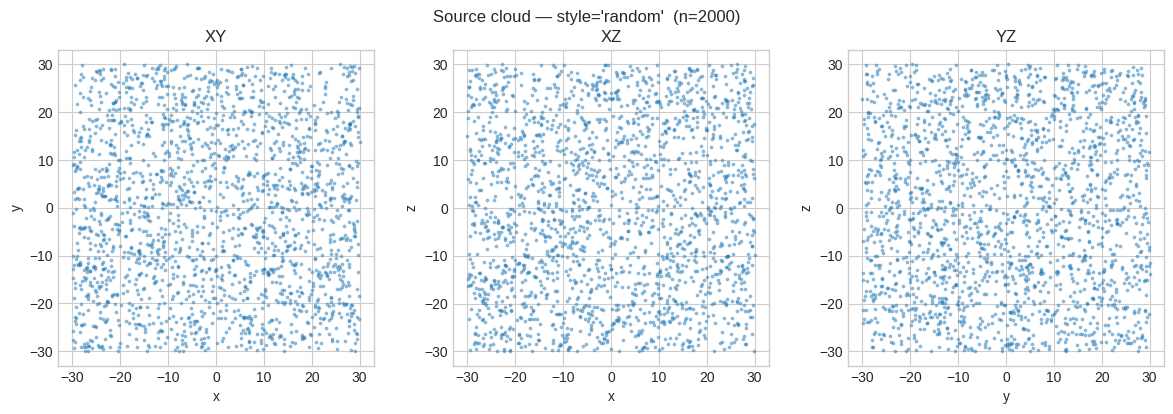

In [3]:
visualize_cloud('random')

random: 100%|██████████| 30/30 [00:14<00:00,  2.06it/s]


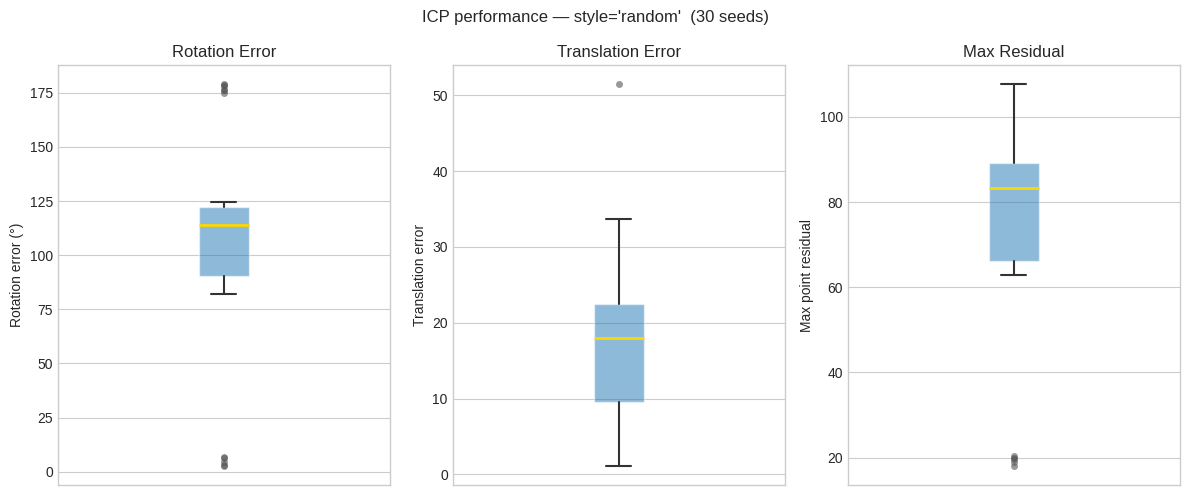

In [4]:
metrics_random = eval_seeds('random')
plot_boxplots(metrics_random, 'random')

## 2. Clustered

8 dense Gaussian clusters with centres placed randomly in $[-20, 20]^3$.  Each cluster acts as a distinct spatial anchor: an incorrect rotation that swaps two clusters incurs a large residual, giving ICP a strong signal to correct the alignment.

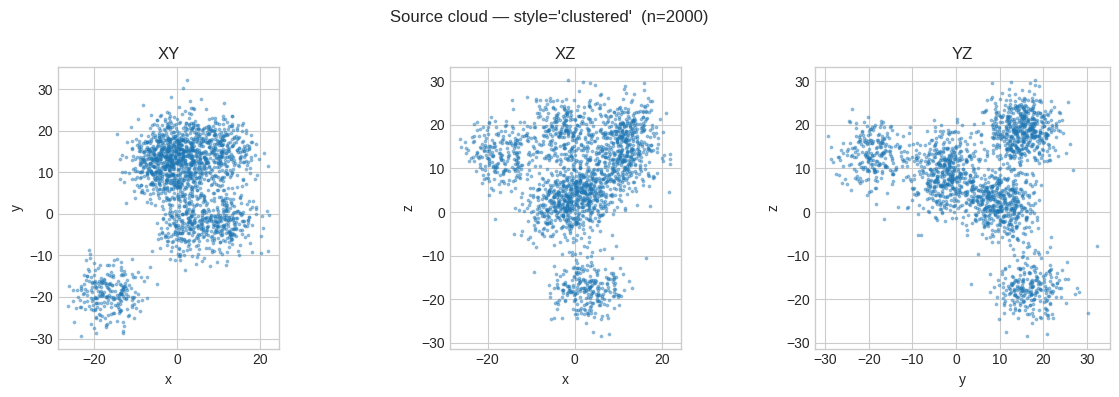

In [5]:
visualize_cloud('clustered')

clustered: 100%|██████████| 30/30 [00:12<00:00,  2.48it/s]


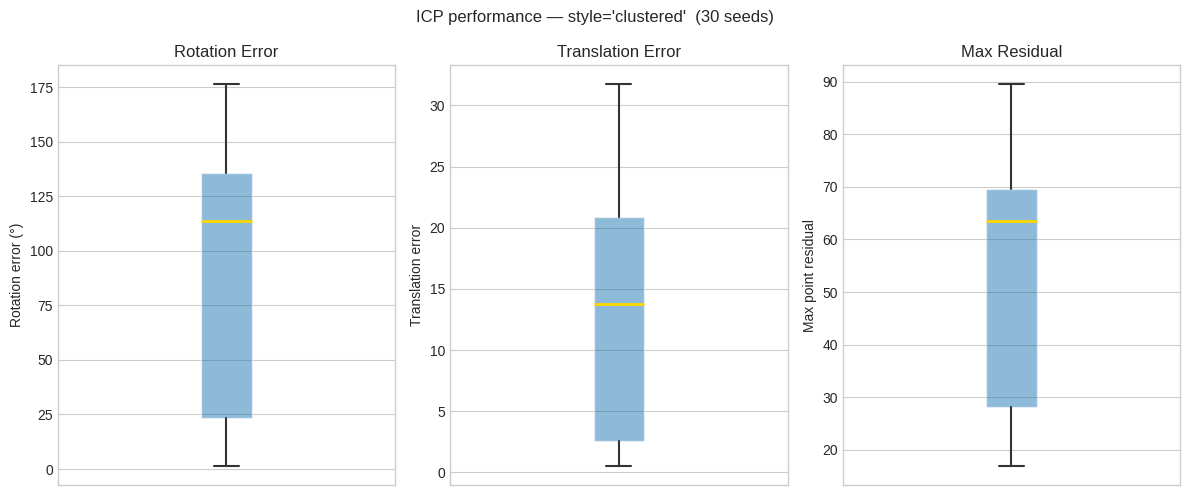

In [6]:
metrics_clustered = eval_seeds('clustered')
plot_boxplots(metrics_clustered, 'clustered')

## 3. Lattice

3-D regular grid with anisotropic spacing $(2, 3.5, 6)$ along $(x, y, z)$ and slight per-node jitter.  The different spacing per axis makes rotations distinguishable: swapping $x$ and $z$ visibly changes inter-point distances.

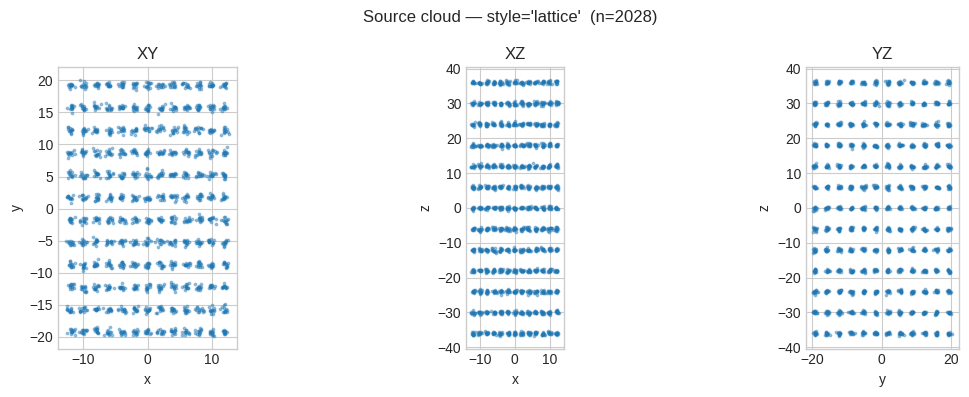

In [7]:
visualize_cloud('lattice')

lattice: 100%|██████████| 30/30 [00:15<00:00,  1.97it/s]


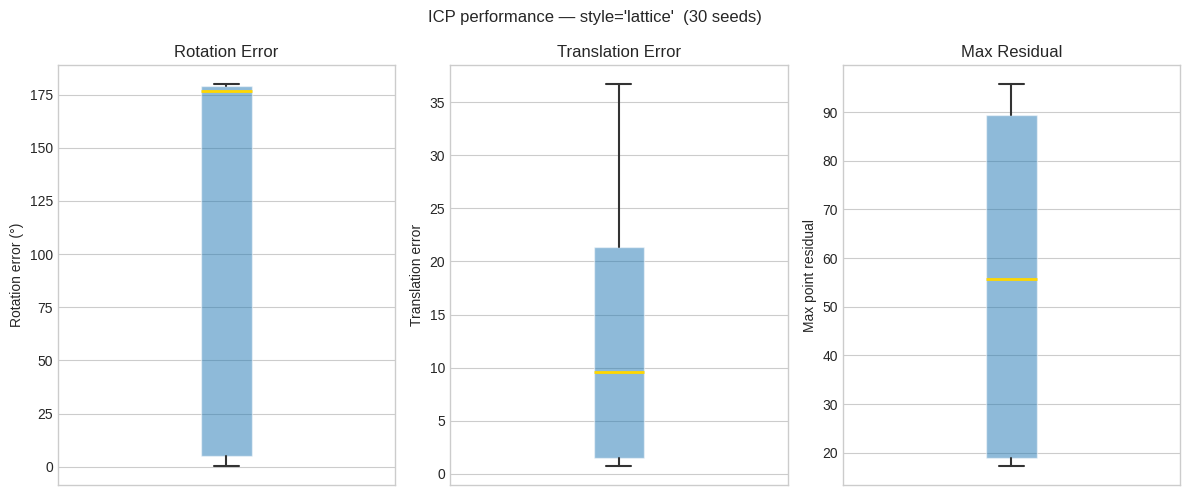

In [8]:
metrics_lattice = eval_seeds('lattice')
plot_boxplots(metrics_lattice, 'lattice')

## 4. Style comparison

All three styles on the same scale.

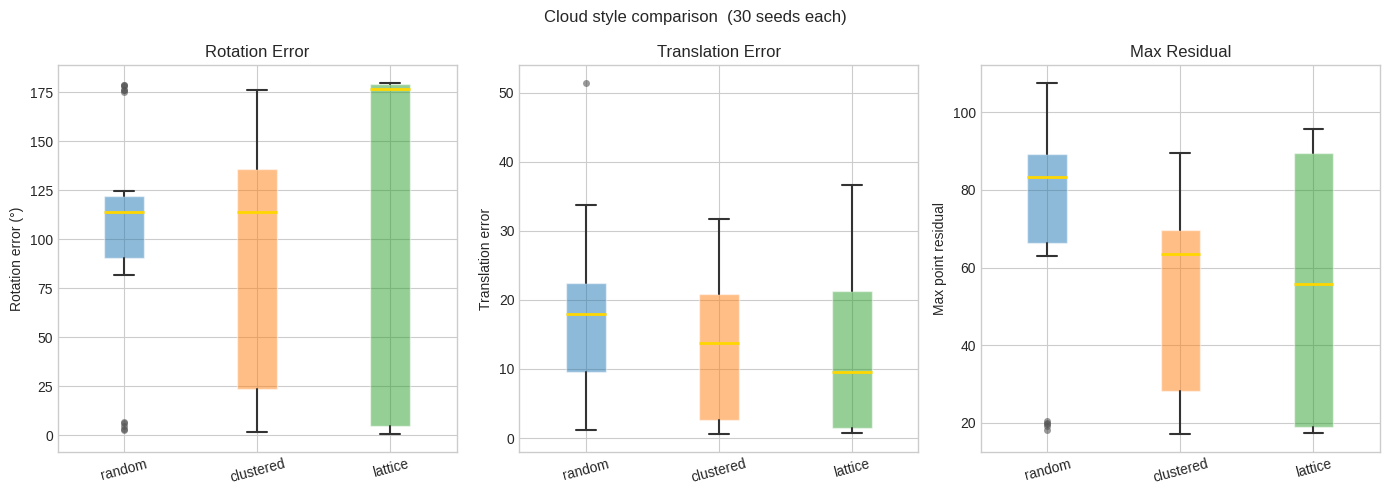

In [9]:
STYLES = ['random', 'clustered', 'lattice']
COLORS = ['tab:blue', 'tab:orange', 'tab:green']
all_metrics = {
    'random':    metrics_random,
    'clustered': metrics_clustered,
    'lattice':   metrics_lattice,
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (key, ylabel, title) in zip(axes, METRICS):
    data = [all_metrics[s][key] for s in STYLES]
    bp = ax.boxplot(data, vert=True, tick_labels=STYLES, **BOX_STYLE)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle(f'Cloud style comparison  ({N_SEEDS} seeds each)')
plt.tight_layout()
plt.savefig('../results/4_cloud_styles_comparison.png', dpi=150, bbox_inches='tight')
plt.show()